# 01 – Análisis Exploratorio del Dataset (EDA)

---

### Objetivos
1. Parsear el `data.yaml` del dataset y entender las clases y particiones.
2. Analizar distribución de imágenes por split y por clase.
3. Explorar características de las bounding boxes (tamaño, posición, densidad).
4. Analizar propiedades radiométricas de las imágenes (brillo, contraste).
5. Identificar posibles problemas: desbalance, imágenes sin anotaciones, bbox muy pequeñas.

## 0. Setup

In [22]:
import sys
from pathlib import Path

# Hacer accesible src/ desde los notebooks
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
import yaml
from PIL import Image
import random

from src.dataset import load_annotations_df, get_image_stats
from src.visualize import plot_samples_with_boxes

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('mako')
pd.set_option('display.float_format', '{:.4f}'.format)

print('✓ Librerías importadas correctamente.')

✓ Librerías importadas correctamente.


## 1. Configuración de rutas y dataset

In [12]:
DATA_ROOT = ROOT / 'data' / 'bone-fracture-detection-daoon-1'
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)


# Chequeamos si el dataset está descargado, sino damos instrucciones 
if not DATA_ROOT.exists():
    print(f'⚠️  Dataset no encontrado en:\n   {DATA_ROOT}')
    print('   Seguí las instrucciones en data/README.md para descargarlo.')
else:
    print(f'✓ Dataset encontrado en: {DATA_ROOT}')

# Cargar data.yaml
DATA_YAML = DATA_ROOT / 'data.yaml'
with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

print('\n📋 Configuración del dataset:')
print(f'   Clases ({data_cfg["nc"]}): {data_cfg["names"]}')

SPLITS = ['train', 'valid', 'test']
CLASS_NAMES = data_cfg['names']

✓ Dataset encontrado en: C:\Users\lbritez\Desktop\CEIA\vpc_II\TP\VPCII_TP_CEIA\data\bone-fracture-detection-daoon-1

📋 Configuración del dataset:
   Clases (7): ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus', 'humerus fracture', 'shoulder fracture', 'wrist positive']


## 2. Estadísticas generales por split

In [13]:
# 
dfs = {} 
img_counts = {}
empty_counts = {}  # imágenes sin anotaciones

for split in SPLITS:
    split_dir = DATA_ROOT / split
    dfs[split] = load_annotations_df(split_dir, class_names=CLASS_NAMES)
    all_imgs = list((split_dir / 'images').glob('*.jpg')) + \
               list((split_dir / 'images').glob('*.png'))
    img_counts[split] = len(all_imgs)
    imgs_with_annot = dfs[split]['image'].nunique()
    empty_counts[split] = img_counts[split] - imgs_with_annot

summary = pd.DataFrame({
    'Imágenes': img_counts,
    'Anotaciones': {s: len(dfs[s]) for s in SPLITS},
    'Imágenes sin annot.': empty_counts,
    'Bbox/imagen (promedio)': {
        s: round(len(dfs[s]) / img_counts[s], 2) for s in SPLITS
    }
})
print(summary.to_string())

       Imágenes  Anotaciones  Imágenes sin annot.  Bbox/imagen (promedio)
train      3631         2088                 1827                  0.5800
valid       348          204                  175                  0.5900
test        169           96                   86                  0.5700


## 3. Distribución de clases por split

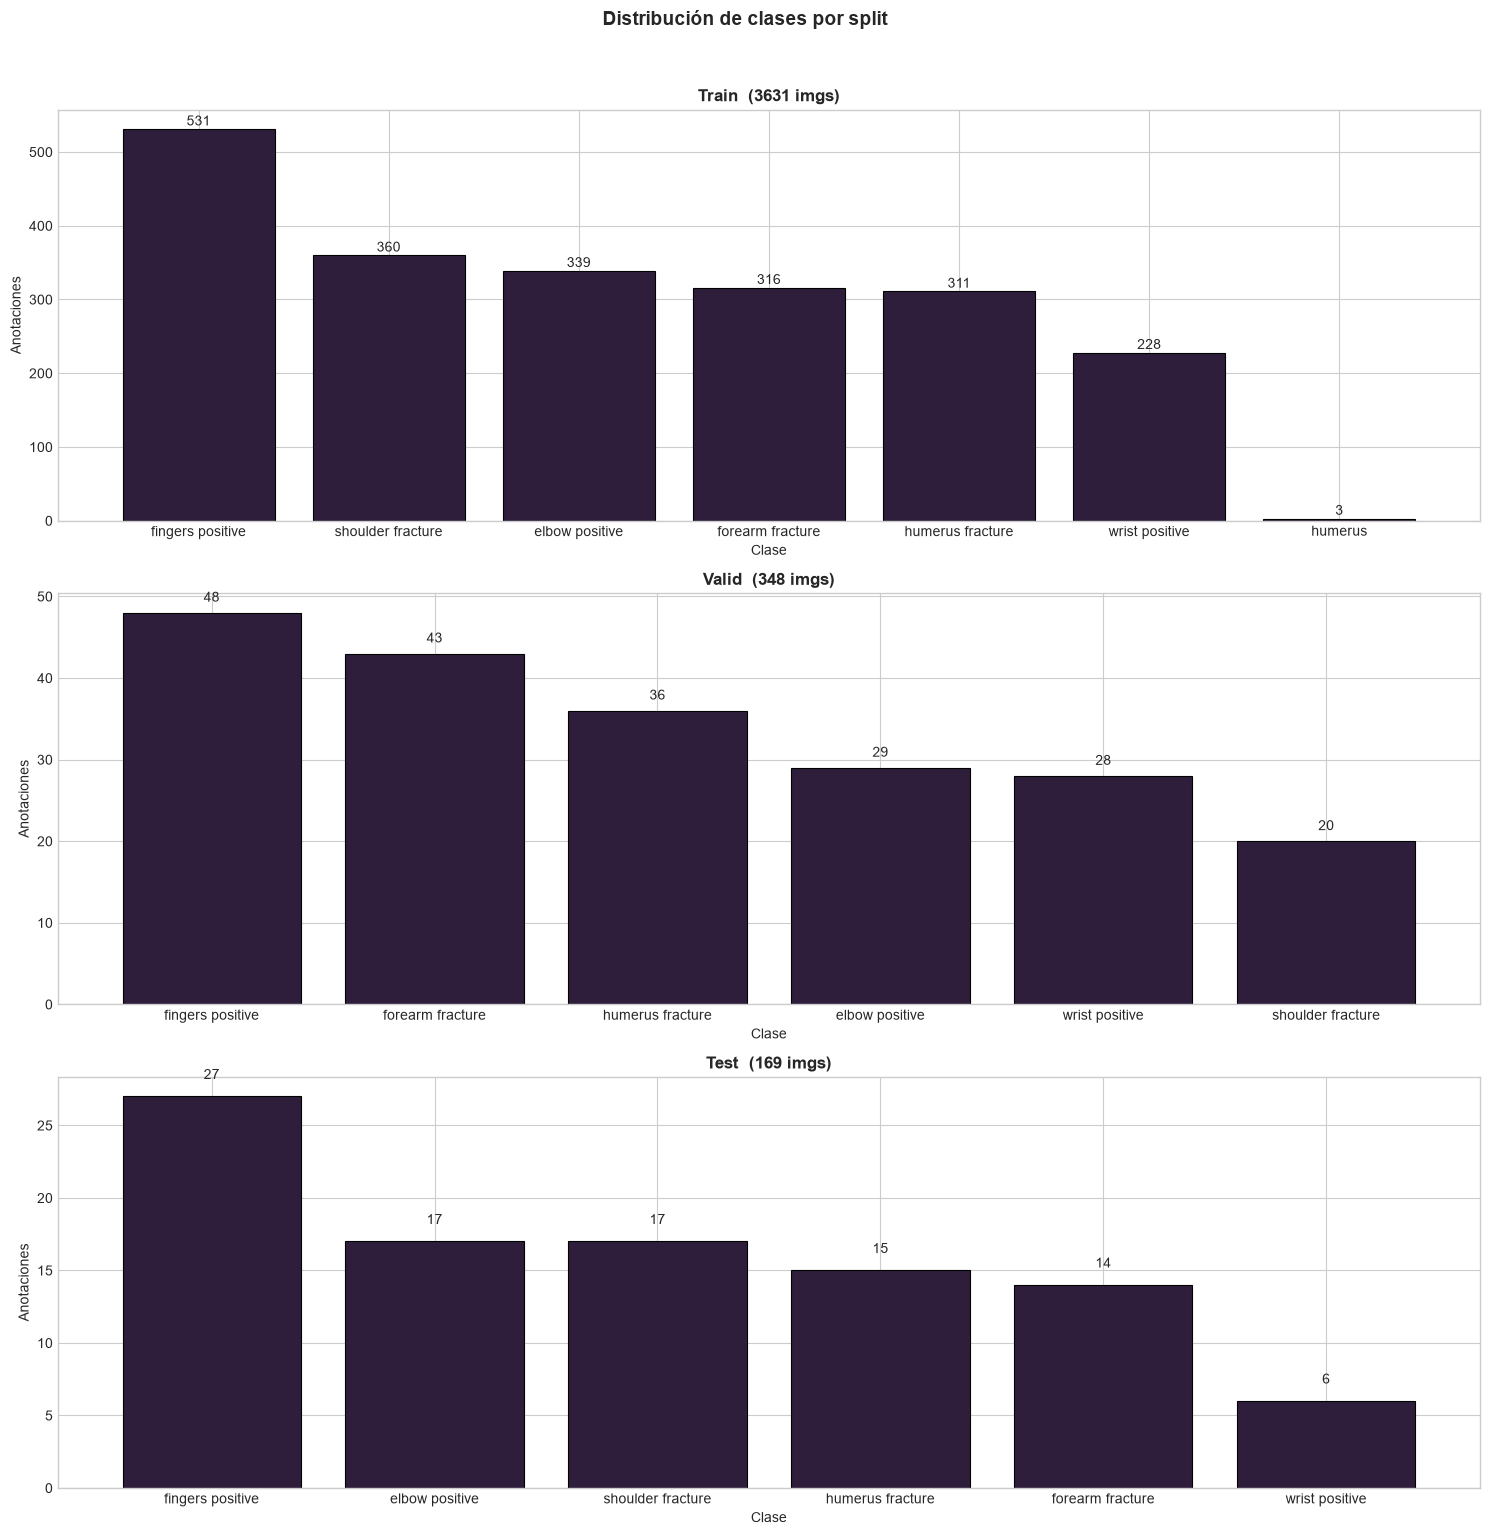

✓ Guardado en results/01_class_distribution.png


In [17]:
fig, axes = plt.subplots(3, 1, figsize=(5 * len(SPLITS), 15), sharey=False)

for ax, split in zip(axes, SPLITS):
    counts = dfs[split]['class_name'].value_counts()
    bars = ax.bar(counts.index, counts.values, edgecolor='black', linewidth=0.8)
    ax.set_title(f'{split.capitalize()}  ({img_counts[split]} imgs)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Anotaciones')
    ax.set_xlabel('Clase')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

plt.suptitle('Distribución de clases por split', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado en results/01_class_distribution.png')

## 4. Distribución de tamaño de bounding boxes

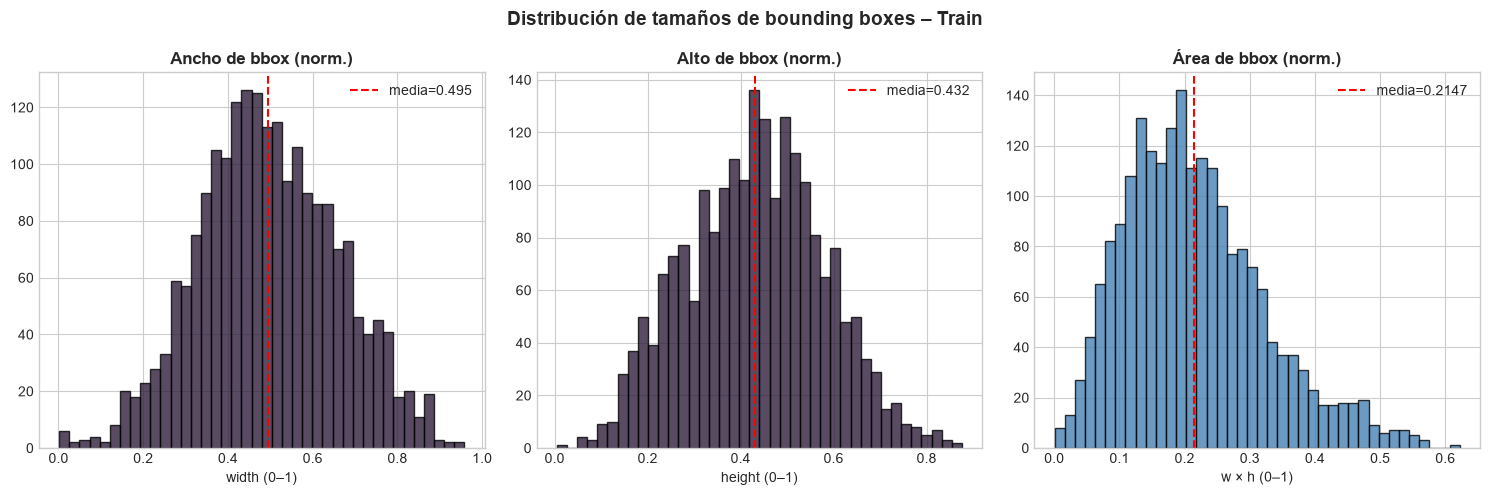

Estadísticas descriptivas (Train):


,bbox_w,bbox_h,bbox_area
count,2088.0000,2088.0000,2088.0000
mean,0.4952,0.4316,0.2147
std,0.1633,0.1483,0.1070
min,0.0015,0.0048,0.0005
25%,0.3816,0.3250,0.1356
50%,0.4870,0.4356,0.2006
75%,0.6105,0.5324,0.2787
max,0.9578,0.8762,0.6221


In [18]:
train_df = dfs['train']

# Calcular área normalizada
train_df = train_df.copy()
train_df['bbox_area'] = train_df['bbox_w'] * train_df['bbox_h']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(train_df['bbox_w'], bins=40, edgecolor='black', alpha=0.8)
axes[0].set_title('Ancho de bbox (norm.)', fontweight='bold')
axes[0].set_xlabel('width (0–1)')
axes[0].axvline(train_df['bbox_w'].mean(), color='red', linestyle='--', label=f'media={train_df["bbox_w"].mean():.3f}')
axes[0].legend()

axes[1].hist(train_df['bbox_h'], bins=40, edgecolor='black', alpha=0.8)
axes[1].set_title('Alto de bbox (norm.)', fontweight='bold')
axes[1].set_xlabel('height (0–1)')
axes[1].axvline(train_df['bbox_h'].mean(), color='red', linestyle='--', label=f'media={train_df["bbox_h"].mean():.3f}')
axes[1].legend()

axes[2].hist(train_df['bbox_area'], bins=40, edgecolor='black', alpha=0.8, color='steelblue')
axes[2].set_title('Área de bbox (norm.)', fontweight='bold')
axes[2].set_xlabel('w × h (0–1)')
axes[2].axvline(train_df['bbox_area'].mean(), color='red', linestyle='--', label=f'media={train_df["bbox_area"].mean():.4f}')
axes[2].legend()

plt.suptitle('Distribución de tamaños de bounding boxes – Train', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_bbox_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Estadísticas descriptivas (Train):')
display(train_df[['bbox_w', 'bbox_h', 'bbox_area']].describe())

## 5. Mapa de calor de posiciones de bbox (centro)

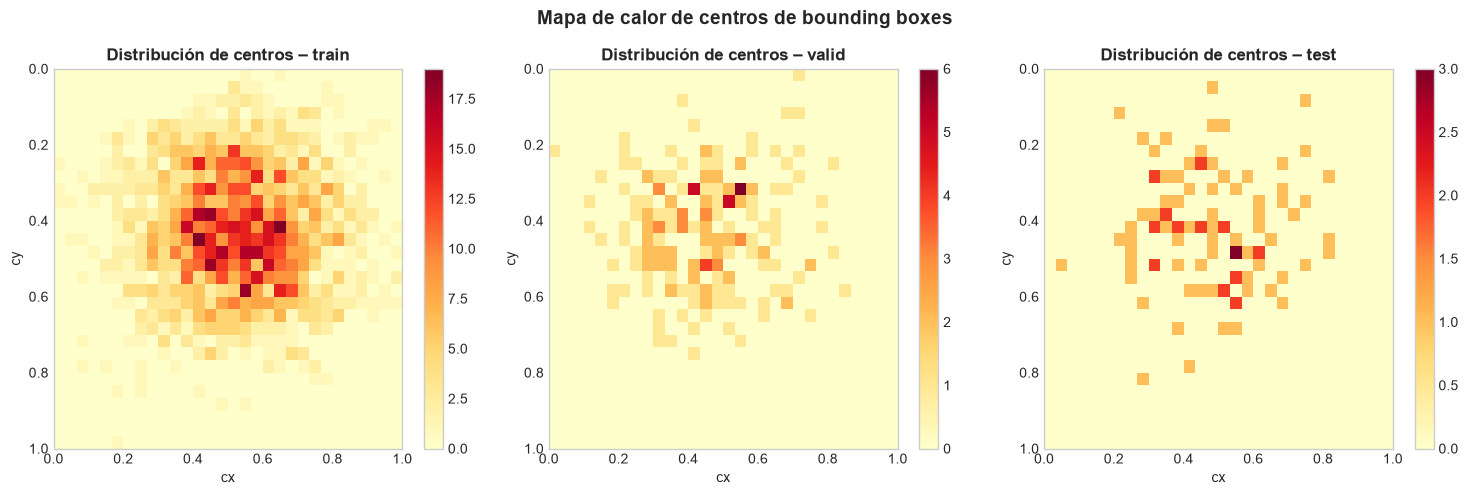

In [19]:
fig, axes = plt.subplots(1, len(SPLITS), figsize=(5 * len(SPLITS), 5))

for ax, split in zip(axes, SPLITS):
    df = dfs[split]
    h = ax.hist2d(df['cx'], df['cy'], bins=30, cmap='YlOrRd', range=[[0,1],[0,1]])
    plt.colorbar(h[3], ax=ax)
    ax.set_title(f'Distribución de centros – {split}', fontweight='bold')
    ax.set_xlabel('cx')
    ax.set_ylabel('cy')
    ax.invert_yaxis()  # (0,0) = esquina superior izquierda como en imágenes

plt.suptitle('Mapa de calor de centros de bounding boxes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_bbox_center_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Análisis de propiedades radiométricas (brillo y contraste)

Total imágenes analizadas: 3631


,width,height,aspect_ratio,mean_brightness,std_brightness
count,3631.0000,3631.0000,3631.0000,3631.0000,3631.0000
mean,412.0333,485.7419,0.8836,54.0683,33.5254
std,115.3996,77.9259,0.3500,38.0901,16.0396
min,111.0000,134.0000,0.2170,0.7700,1.9400
25%,379.0000,492.0000,0.7400,26.6100,22.1050
50%,420.0000,512.0000,0.8200,46.0200,30.7500
75%,512.0000,512.0000,1.0410,70.6350,42.6150
max,2048.0000,2048.0000,3.8210,212.0600,99.7400


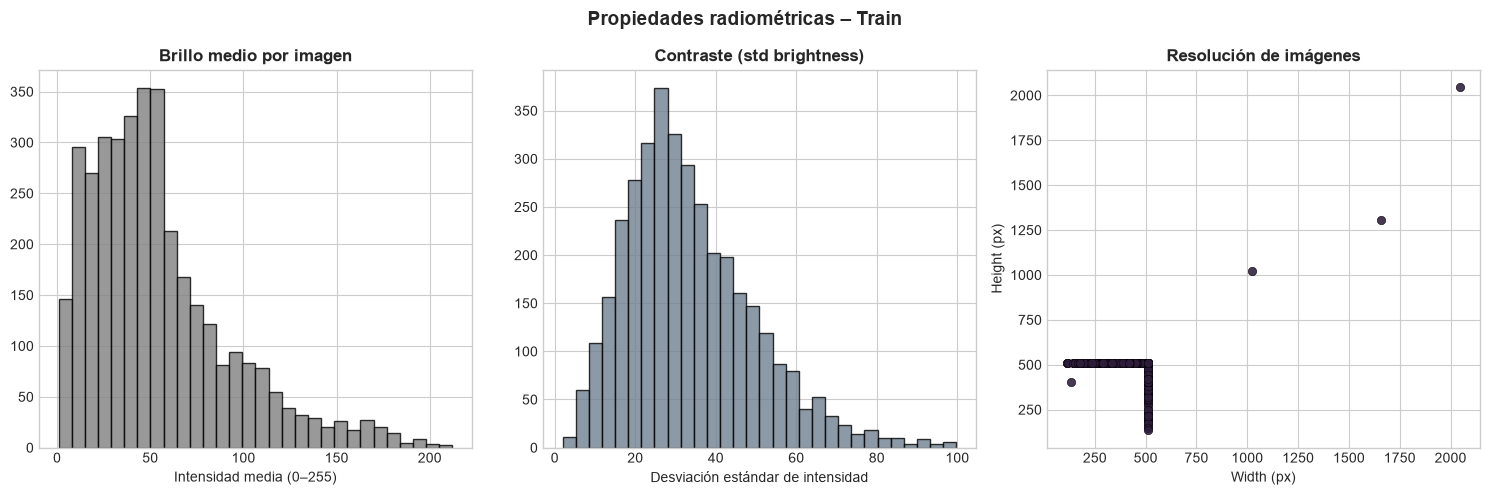

In [20]:
img_stats = get_image_stats(DATA_ROOT / 'train' / 'images')

print(f'Total imágenes analizadas: {len(img_stats)}')
display(img_stats[['width', 'height', 'aspect_ratio', 'mean_brightness', 'std_brightness']].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(img_stats['mean_brightness'], bins=30, edgecolor='black', color='gray', alpha=0.8)
axes[0].set_title('Brillo medio por imagen', fontweight='bold')
axes[0].set_xlabel('Intensidad media (0–255)')

axes[1].hist(img_stats['std_brightness'], bins=30, edgecolor='black', color='slategray', alpha=0.8)
axes[1].set_title('Contraste (std brightness)', fontweight='bold')
axes[1].set_xlabel('Desviación estándar de intensidad')

axes[2].scatter(img_stats['width'], img_stats['height'], alpha=0.5, edgecolors='black', linewidths=0.3)
axes[2].set_title('Resolución de imágenes', fontweight='bold')
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')

plt.suptitle('Propiedades radiométricas – Train', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_image_properties.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Visualización de muestras con anotaciones

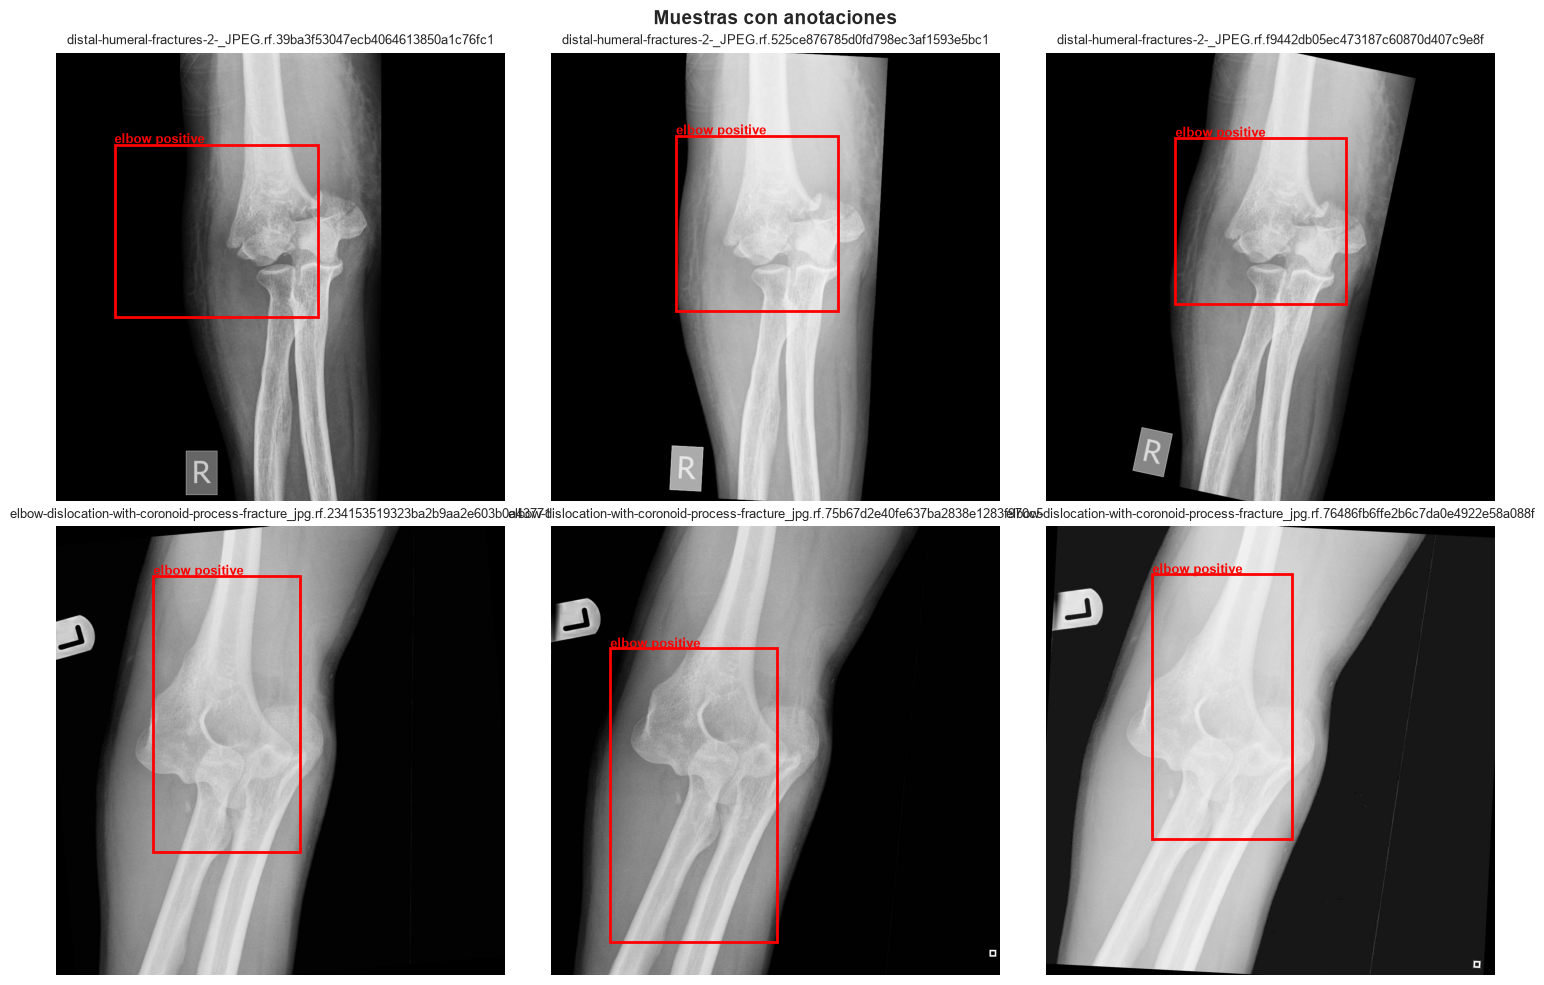

✓ Guardado en results/01_sample_annotations.png


In [21]:
plot_samples_with_boxes(
    data_dir=DATA_ROOT / 'train',
    annotations_df=dfs['train'],
    n_samples=6,
    save_path=RESULTS_DIR / '01_sample_annotations.png'
)
print('✓ Guardado en results/01_sample_annotations.png')

## 8. Histograma de píxeles por canal (medias del split train)

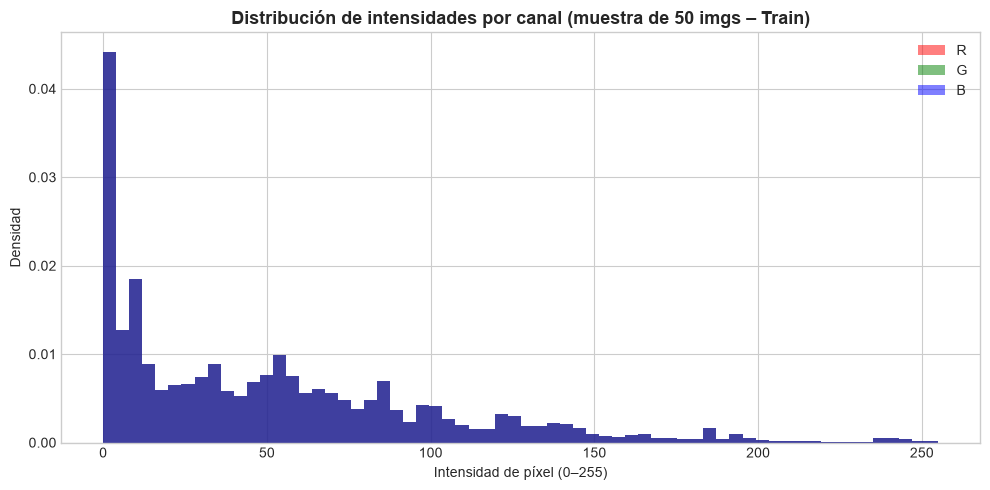

✓ Guardado en results/01_pixel_histogram.png


In [23]:
# Usamos random para el sampleo 

train_imgs = list((DATA_ROOT / 'train' / 'images').glob('*.jpg'))
sample_imgs = random.sample(train_imgs, min(50, len(train_imgs)))

r_vals, g_vals, b_vals = [], [], []
for img_path in sample_imgs:
    img = np.array(Image.open(img_path).convert('RGB'))
    r_vals.extend(img[:, :, 0].flatten().tolist())
    g_vals.extend(img[:, :, 1].flatten().tolist())
    b_vals.extend(img[:, :, 2].flatten().tolist())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(r_vals, bins=64, color='red',   alpha=0.5, label='R', density=True)
ax.hist(g_vals, bins=64, color='green', alpha=0.5, label='G', density=True)
ax.hist(b_vals, bins=64, color='blue',  alpha=0.5, label='B', density=True)
ax.set_title('Distribución de intensidades por canal (muestra de 50 imgs – Train)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Intensidad de píxel (0–255)')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_pixel_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado en results/01_pixel_histogram.png')

---
## 9. Conclusiones del EDA

*(Completar tras ejecutar el análisis)*

| Aspecto | Observación | Impacto en el entrenamiento |
|---------|-------------|-----------------------------|
| Balance de clases | ... | ... |
| Tamaño típico de bbox | ... | ... |
| Distribución espacial | ... | ... |
| Variabilidad de brillo | ... | ... |
| Resolución de imágenes | ... | ... |
| Imágenes sin anotaciones | ... | ... |